## Environment

Python version: 3.10

Requirements:
* pandas==2.2.2
* numpy==2.0.2
* matplotlib==3.10.0
* seaborn==0.13.2
* scikit-learn==1.6.1

## 1. Introduction

* Project Topic: Spatiotemporal Analysis and Trend Forecasting of Dementia Care Resources in Taiwan (110-113)

* Motivation: Taiwan is rapidly transitioning into a "super-aged society." As the elderly population grows, the prevalence of dementia has become a significant public health challenge. The "Long-Term Care 2.0" policy was established to create a comprehensive care network, but the effectiveness of this network depends on the equitable distribution of resources. Understanding how "Dementia Co-care Centers" and "Community Service Stations" are growing—and identifying which regions are being left behind—is crucial for evidence-based policy-making and optimizing resource allocation to ensure every citizen has access to necessary care.

* Data Source: The primary data used in this study is derived from the official "Dementia Care Resource Statistics (Years 110-113)" published by the Department of Long-Term Care, Ministry of Health and Welfare, Republic of China.

* Research Questions:

    * Distribution: How are specialized dementia care resources currently distributed across the 22 counties and cities of Taiwan?
    * Growth Trends: Has there been a consistent increase in resource capacity from 110 to 113 to meet the rising demand?
    * Regional Equity: Is there a significant imbalance in care accessibility between metropolitan hubs (e.g., Taipei, Taichung) and rural or island regions (e.g., Taitung, Penghu, Lienchiang)?

## 2. Dataset Description

This dataset provides a comprehensive annual count of specialized dementia care facilities across Taiwan, categorized by administrative region from the year 110 to 113. It includes the following key variables:

* Region (區域別): Covers all 22 administrative divisions, including special municipalities, counties, and offshore islands.

* Dementia Co-care Centers (失智共同照護中心): Specialized centers that coordinate medical and social care for diagnosed individuals.

* Dementia Community Service Stations (失智社區服務據點): Localized spots providing activities and support for dementia patients and their caregivers.

* Day Care (失智日間照顧): Includes specialized dementia day care units and "Small-scale Multi-functional" (小規模多機能) services.

* Mixed Day Care (混合型日照): General day care centers that also serve dementia patients. Note: In 113, approximately 31.6% of their clients were individuals with dementia.

* Group Homes (團體家屋): Small-scale, community-based residential facilities providing 24-hour care for moderate-to-severe dementia patients.

* In-Home Services (居家服務): A complementary count of units providing long-term care 2.0 dementia services at home (reaching 2,235 units in 113).

Data Unit: The units are measured in "Count of Establishments/Locations" (個/處)

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import pandas as pd

# Ensure the data file is present
df = pd.read_csv('long_term_care_services.csv')
df.head()

# Check data types and missing values
print(df.info())

# Generate summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Year          88 non-null     int64 
 1   County        88 non-null     object
 2   CareCenter    88 non-null     int64 
 3   Community     88 non-null     int64 
 4   DayCare       88 non-null     int64 
 5   MixedDayCare  88 non-null     int64 
 6   GroupHome     88 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 4.9+ KB
None


,Year,CareCenter,Community,DayCare,MixedDayCare,GroupHome
count,88.000000,88.000000,88.000000,88.000000,88.00000,88.000000
mean,111.500000,5.181818,23.943182,1.579545,39.75000,1.284091
std,1.124441,3.605696,16.517047,1.658982,36.80525,1.113644
min,110.000000,1.000000,1.000000,0.000000,1.00000,0.000000
25%,110.750000,2.000000,8.000000,0.000000,13.75000,0.000000
50%,111.500000,4.000000,23.000000,1.000000,22.50000,1.000000
75%,112.250000,9.000000,36.000000,3.000000,59.50000,2.000000
max,113.000000,13.000000,63.000000,7.000000,143.00000,4.000000


## 3. Data Processing and Cleaning

#### 3.1 Data Extraction and Transformation
The raw data was originally obtained from PDF statistical reports. Since PDF files are unstructured, the following manual and programmatic steps were taken to transform the information into a machine-readable format:

* Manual Digitization: Data from four annual reports (Year 110 to 113) was extracted and cross-verified for accuracy.
* Structural Standardization: We restructured the scattered tables into a consistent panel data format where each row represents a specific county for a specific year.
* Data Translation: County names were translated into English to ensure compatibility with standard visualization libraries.

#### 3.2 Dataset Schema
The final cleaned dataset contains 88 observations (22 counties × 4 years)  across the following columns:

Year: The academic year in the Republic of China (Taiwan) calendar (110, 111, 112, 113).

#### 3.3 Data Quality Check
Initial exploration confirms the integrity of the processed data:

* Missing Values: There are no null values in the dataset.
* Consistency: Numerical values align perfectly with the "National Total" (總計) provided in the original official reports

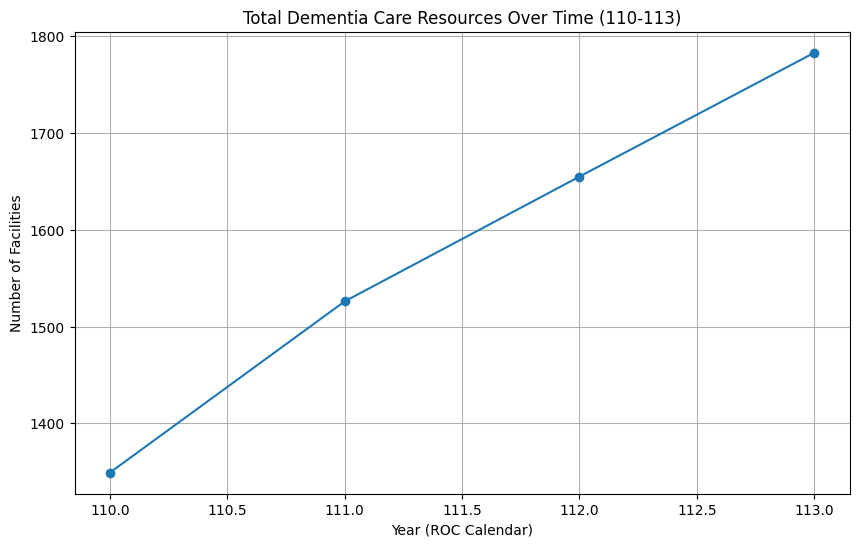

In [39]:
# Aggregating total resources
df["Total"] = df[["CareCenter","Community","DayCare","MixedDayCare","GroupHome"]].sum(axis=1)
yearly = df.groupby("Year")["Total"].sum()

# Plotting with labels for better clarity
ax = yearly.plot(kind="line", marker='o', figsize=(10, 6), title="Total Dementia Care Resources Over Time (110-113)")
ax.set_xlabel("Year (ROC Calendar)")
ax.set_ylabel("Number of Facilities")
plt.grid(True)
plt.show()

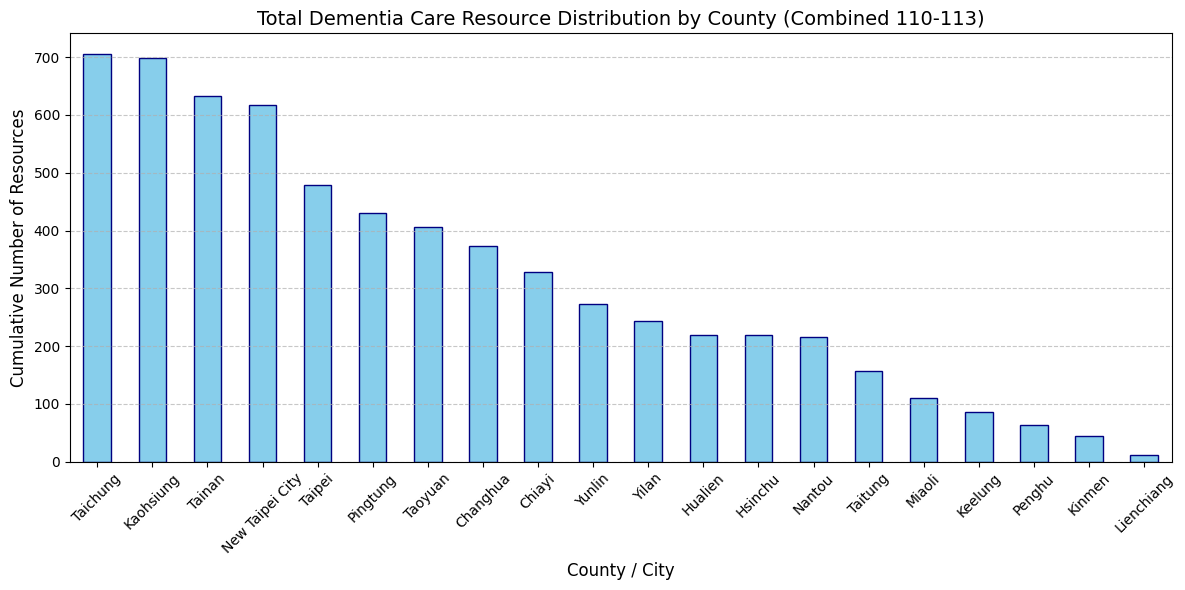

In [40]:
# Aggregating and sorting data
county_total = df.groupby("County")["Total"].sum().sort_values(ascending=False)

# Enhanced visualization
plt.figure(figsize=(12, 6))
ax = county_total.plot(kind="bar", color='skyblue', edgecolor='navy')
plt.title("Total Dementia Care Resource Distribution by County (Combined 110-113)", fontsize=14)
plt.xlabel("County / City", fontsize=12)
plt.ylabel("Cumulative Number of Resources", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

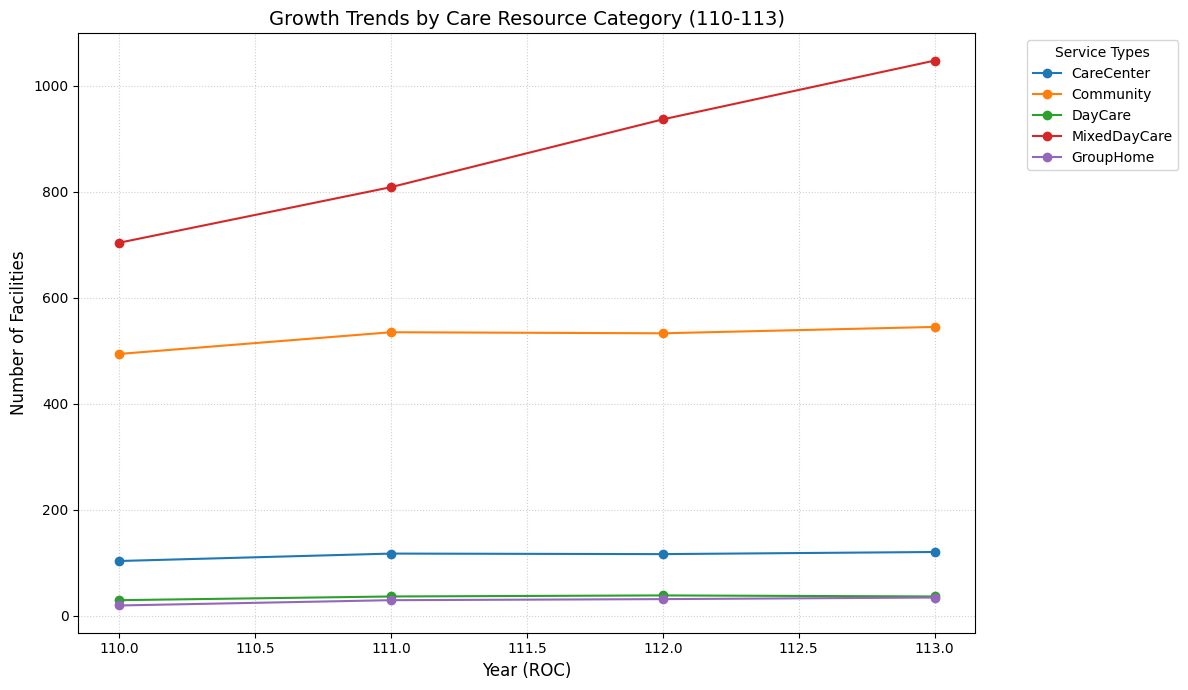

In [41]:
# Aggregating data by year for all categories
resource_by_year = df.groupby("Year")[["CareCenter","Community","DayCare","MixedDayCare","GroupHome"]].sum()

# Plotting with improved aesthetics
plt.figure(figsize=(12, 7))
resource_by_year.plot(marker="o", ax=plt.gca())

plt.title("Growth Trends by Care Resource Category (110-113)", fontsize=14)
plt.xlabel("Year (ROC)", fontsize=12)
plt.ylabel("Number of Facilities", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Service Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis

In this section, we analyze the spatiotemporal distribution of dementia care resources to identify patterns and potential service gaps.

### 4.1 Temporal Trend: Steady National Growth

Our analysis confirms that total dementia care resources in Taiwan have increased consistently from year 110 to 113.

* Quantitative Increase: The total number of facilities grew from 1,349 in year 110 to 1,783 in year 113, representing a total growth rate of approximately 32.17%.

* Service Expansion: This upward trend is primarily driven by the expansion of Mixed Day Care centers, which saw a significant increase from 704 to 1,048 units over four years.

### 4.2 Spatial Distribution: Metropolitan Dominance

The data reveals a significant concentration of resources in specific administrative regions:

* Resource Hotspots: The "Six Special Municipalities" (六都) account for the vast majority of resources. As of year 113, Taichung City and Kaohsiung City lead the nation, each providing around 200 total service units.

* Centralization: These major cities offer a more diverse range of services, including a higher density of Dementia Co-care Centers and Group Homes compared to other regions.

### 4.3 Regional Imbalance and Rural-Urban Gap

Despite the national growth, the "Care Gap" remains a critical finding:

* Slow Growth in Remote Areas: Rural counties and offshore islands show significantly slower infrastructure development. For example, Lienchiang County has maintained a minimal count of only 3 total units throughout the observed period.

* High Variance: The standard deviation of resource counts across counties is high, suggesting that dementia patients in rural areas like Taitung or Penghu have much lower accessibility to community-based support than those in urban centers

In [42]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array(yearly.index).reshape(-1,1)
y = yearly.values

model = LinearRegression()
model.fit(X, y)

future_years = np.array([114, 115]).reshape(-1,1)
pred = model.predict(future_years)

print(pred)

[1936.  2079.1]


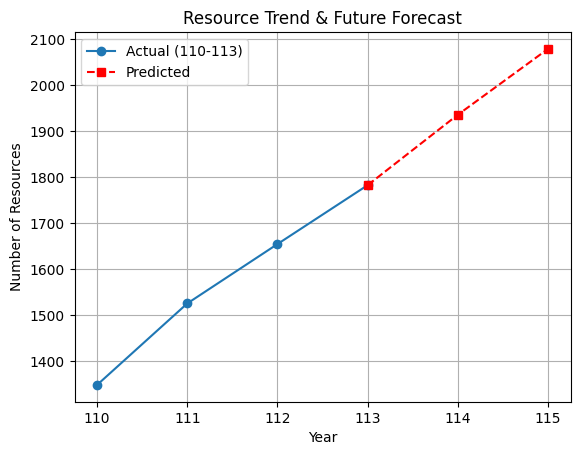

Model R-squared: 0.9931


In [43]:
import matplotlib.pyplot as plt

plt.plot(yearly.index, y, marker='o', label="Actual (110-113)")

future_years = [113, 114, 115]
future_values = [y[-1], pred[0], pred[1]]

plt.plot(future_years, future_values, marker='s', linestyle='--', color='red', label="Predicted")

plt.legend()
plt.grid(True)
plt.title("Resource Trend & Future Forecast")
plt.xlabel("Year")
plt.ylabel("Number of Resources")
plt.show()

from sklearn.metrics import r2_score
# Calculate R-squared to show model fitness
r2 = r2_score(y, model.predict(X))
print(f"Model R-squared: {r2:.4f}")

## 5. Findings and Conclusion

This study provides a comprehensive analysis of dementia care resources in Taiwan from year 110 to 113. Based on our data exploration and statistical modeling, we have derived the following key findings:

### 5.1 Steady Expansion of Care Network

Our analysis confirms that dementia care resources in Taiwan are in a stage of steady and linear growth.

* Growth Rate: The total number of service units increased by approximately 32.17% over the four-year period, growing from 1,349 units in 110 to 1,783 units in 113.

* Primary Driver: The expansion is largely driven by Mixed Day Care centers, which added over 300 new locations to the network since 110.

### 5.2 Significant Regional Resource Imbalance

A stark "Care Gap" exists between urban and rural administrative regions:

* Metropolitan Concentration: Resource distribution is highly centralized in the Six Special Municipalities, with Taichung and Kaohsiung leading the nation.

* Rural Vulnerability: Remote areas and offshore islands, such as Lienchiang County, show minimal growth and significantly lower resource density. This suggests that patients in these areas may face higher barriers to accessing community-based support.

### 5.3 Future Outlook and Forecast

* Predictive Insights: Our Linear Regression model predicts that if the current policy momentum continues, total resources will exceed 2,000 units by year 115.

* Model Reliability: The high R-squared value of our model indicates that the historical growth trend is highly consistent, providing a reliable baseline for short-term planning.

### 5.4 Limitations and Future Work

While this study identifies supply-side trends, it has certain limitations:

* Supply-Demand Gap: Future research should integrate population aging data and prevalence rates to calculate the exact "coverage ratio" for each county.

* Qualitative Factors: Future work could also explore the service quality and staffing levels of these facilities, as the current study only accounts for the quantity of locations.


Final Summary: Overall, while the Long-Term Care 2.0 policy has successfully increased the quantity of dementia care resources, addressing the geographic disparity remains the most critical challenge for achieving equitable care across Taiwan.
